## Konstrukcija novih značajki

Kako bi se poboljšala kvaliteta analize i omogućilo otkrivanje skrivenih obrazaca u podacima, konstruirane su nove značajke iz postojećih atributa.

Cilj feature engineeringa je stvoriti dodatne informacije koje bolje opisuju karakteristike Airbnb smještaja te mogu poboljšati rezultate prediktivnih modela i klasteriranja.

In [1]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt

from sklearn.model_selection import train_test_split
from sklearn.preprocessing import StandardScaler
from sklearn.tree import DecisionTreeClassifier, plot_tree
from sklearn.ensemble import RandomForestClassifier
from sklearn.metrics import accuracy_score, precision_score, recall_score, f1_score, confusion_matrix, classification_report

from sklearn.cluster import KMeans
from sklearn.metrics import silhouette_score

In [2]:
from google.colab import files
uploaded = files.upload()

Saving airbnb_clean.csv to airbnb_clean.csv


In [3]:
df = pd.read_csv("airbnb_clean.csv")
df.head()

/tmp/ipykernel_923/2599142183.py:1: DtypeWarning: Columns (0) have mixed types. Specify dtype option on import or set low_memory=False.
  df = pd.read_csv("airbnb_clean.csv")


,id,name,host_id,host_identity_verified,host_name,neighbourhood_group,neighbourhood,lat,long,country,...,room_type,construction_year,price,service_fee,minimum_nights,number_of_reviews,reviews_per_month,review_rate_number,calculated_host_listings_count,availability_365
0,1001254,Clean & quiet apt home by the park,8.001449e+10,unconfirmed,Madaline,Brooklyn,Kensington,40.64749,-73.97237,United States,...,Private room,2020.0,966.0,193.0,10.0,9.0,0.21,4.0,6.0,286.0
1,1002102,Skylit Midtown Castle,5.233517e+10,verified,Jenna,Manhattan,Midtown,40.75362,-73.98377,United States,...,Entire home/apt,2007.0,142.0,28.0,30.0,45.0,0.38,4.0,2.0,228.0
2,1002755,Water View King Bed Hotel Room,8.509833e+10,unconfirmed,Garry,Brooklyn,Clinton Hill,40.68514,-73.95976,United States,...,Entire home/apt,2005.0,368.0,74.0,30.0,270.0,4.64,4.0,1.0,322.0
3,1004650,BlissArtsSpace!,6.130061e+10,unconfirmed,Alberta,Brooklyn,Bedford-Stuyvesant,40.68688,-73.95596,United States,...,Private room,2015.0,71.0,14.0,45.0,49.0,0.40,5.0,1.0,224.0
4,1006859,Cute & Cozy Lower East Side 1 bdrm,1.280143e+09,verified,Miranda,Manhattan,Chinatown,40.71344,-73.99037,United States,...,Entire home/apt,2004.0,319.0,64.0,1.0,160.0,1.33,3.0,4.0,1.0


In [7]:
df.columns

Index(['id', 'name', 'host_id', 'host_identity_verified', 'host_name',
       'neighbourhood_group', 'neighbourhood', 'lat', 'long', 'country',
       'country_code', 'instant_bookable', 'cancellation_policy', 'room_type',
       'construction_year', 'price', 'service_fee', 'minimum_nights',
       'number_of_reviews', 'reviews_per_month', 'review_rate_number',
       'calculated_host_listings_count', 'availability_365'],
      dtype='object')

Nove značajke

1. Availability_ratio

In [9]:
df["availability_ratio"] = (
    df["availability_365"] / 365
)
df["availability_ratio"].describe()

,availability_ratio
count,51071.000000
mean,0.377507
std,0.354018
min,0.000000
25%,0.016438
50%,0.268493
75%,0.706849
max,1.000000


2. Professional_host

In [14]:
df["professional_host"] = (
    df["calculated_host_listings_count"] >= 5
).astype(int)

3. Distance_to_center

In [23]:
df = df.dropna(
    subset=["lat","long"]
)

import numpy as np

def haversine(lat1, lon1, lat2, lon2):

    R = 6371

    lat1 = np.radians(lat1)
    lon1 = np.radians(lon1)

    lat2 = np.radians(lat2)
    lon2 = np.radians(lon2)

    dlat = lat2 - lat1
    dlon = lon2 - lon1

    a = (
        np.sin(dlat/2)**2
        + np.cos(lat1)
        * np.cos(lat2)
        * np.sin(dlon/2)**2
    )

    c = 2*np.arctan2(
        np.sqrt(a),
        np.sqrt(1-a)
    )

    return R*c


In [25]:
center_lat = 40.7580
center_lon = -73.9855

df["distance_to_center"] = haversine(
    df["lat"],
    df["long"],
    center_lat,
    center_lon
)

df["distance_to_center"].describe()

,distance_to_center
count,51045.000000
mean,7.384211
std,4.737991
min,0.028960
25%,3.913749
50%,6.668034
75%,9.669288
max,35.941376


4. Popularity_score

In [50]:
from sklearn.preprocessing import StandardScaler
cols = [
    "number_of_reviews",
    "reviews_per_month",
    "review_rate_number"
]
scaler = StandardScaler()

scaled = scaler.fit_transform(
    df[cols]
)
df["popularity_score"] = (
    scaled[:,0]
    + scaled[:,1]
    + scaled[:,2]
)
df["popularity_score"].describe()

,popularity_score
count,5.104500e+04
mean,1.815159e-16
std,2.048956e+00
min,-3.106235e+00
25%,-1.329153e+00
50%,-3.134118e-01
75%,7.187342e-01
max,6.845628e+01


## Sažetak konstruiranih značajki

U ovom poglavlju konstruirane su nove značajke koje opisuju smještajne karakteristike.

Nove značajke koristimo u daljnjim analizama, uključujući prediktivne modele i klasteriranje smještaja.



# Prediktivni modeli

## Predikcija visoke cijene smještaja

Kako bi se identificirali čimbenici koji utječu na cijenu Airbnb smještaja, problem je formuliran kao zadatak binarne klasifikacije.

Cijena smještaja pretvorena je u ciljnu varijablu high_price.

Smještaji čija je cijena veća od medijana cijena označeni su kao smještaji visoke cijene (1), dok su ostali označeni kao smještaji niže cijene (0).

Za predikciju korišteni su modeli Decision Tree i Random Forest.

In [51]:
df["high_price"] = (
    df["price"] >
    df["price"].median()
).astype(int)

df["high_price"].value_counts()

,count
high_price,
0,25649
1,25396


## Kodiranje kategorijskih atributa

Budući da modeli strojnog učenja zahtijevaju numeričke ulazne podatke, kategorijski atributi pretvoreni su u numerički oblik korištenjem metode Label Encoding.

In [52]:
from sklearn.preprocessing import LabelEncoder

In [56]:
le_room = LabelEncoder()

df["room_type_encoded"] = le_room.fit_transform(
    df["room_type"]
)
le_group = LabelEncoder()

df["neighbourhood_group_encoded"] = le_group.fit_transform(
    df["neighbourhood_group"]
)
le_cancel = LabelEncoder()

df["cancellation_policy_encoded"] = le_cancel.fit_transform(
    df["cancellation_policy"]
)
df["instant_bookable"] = (
    df["instant_bookable"]
    .astype(int)
)

## Odabir atributa

Za modeliranje su korištene značajke koje opisuju lokaciju smještaja, dostupnost, popularnost, vrstu smještaja te karakteristike domaćina.

Iz modela su izostavljene značajke koje izravno koriste informaciju o cijeni kako bi se izbjegao problem curenja informacija.

In [77]:
features = [
    "distance_to_center",
    "popularity_score",
    "availability_ratio",
    "professional_host",
    "review_rate_number",
    "number_of_reviews",
    "reviews_per_month",
    "calculated_host_listings_count",
    "room_type_encoded",
    "neighbourhood_group_encoded",
    "cancellation_policy_encoded",
    "instant_bookable"
]

X = df[features]
y = df["high_price"]

## Podjela podataka

Podaci su podijeljeni na skup za treniranje i skup za testiranje u omjeru 80:20.

Za reproduktivnost rezultata korišten je random_state = 42.

In [79]:
from sklearn.model_selection import train_test_split

In [78]:
X_train, X_test, y_train, y_test = train_test_split(
    X,
    y,
    test_size=0.2,
    random_state=42,
    stratify=y
)

In [80]:
X_train.shape, X_test.shape

((40836, 12), (10209, 12))

## Decision Tree

Decision Tree model klasificira smještaje u kategorije visoke i niske cijene na temelju odabranih atributa.

Model donosi odluke kroz niz uzastopnih podjela podataka prema atributima koji najbolje razlikuju promatrane klase.

In [81]:
from sklearn.tree import DecisionTreeClassifier
from sklearn.metrics import (
    accuracy_score,
    precision_score,
    recall_score,
    f1_score,
    confusion_matrix,
    classification_report
)

In [82]:
dt = DecisionTreeClassifier(
    max_depth=5,
    random_state=42
)

dt.fit(X_train, y_train)

y_pred_dt = dt.predict(X_test)

In [83]:
print("Accuracy:", accuracy_score(y_test, y_pred_dt))
print("Precision:", precision_score(y_test, y_pred_dt))
print("Recall:", recall_score(y_test, y_pred_dt))
print("F1:", f1_score(y_test, y_pred_dt))

Accuracy: 0.4923107062395925
Precision: 0.493112582781457
Recall: 0.7330183106910809
F1: 0.5895953757225434


In [84]:
cm = confusion_matrix(y_test, y_pred_dt)

print(cm)

[[1303 3827]
 [1356 3723]]


In [85]:
print(classification_report(y_test, y_pred_dt))

              precision    recall  f1-score   support

           0       0.49      0.25      0.33      5130
           1       0.49      0.73      0.59      5079

    accuracy                           0.49     10209
   macro avg       0.49      0.49      0.46     10209
weighted avg       0.49      0.49      0.46     10209



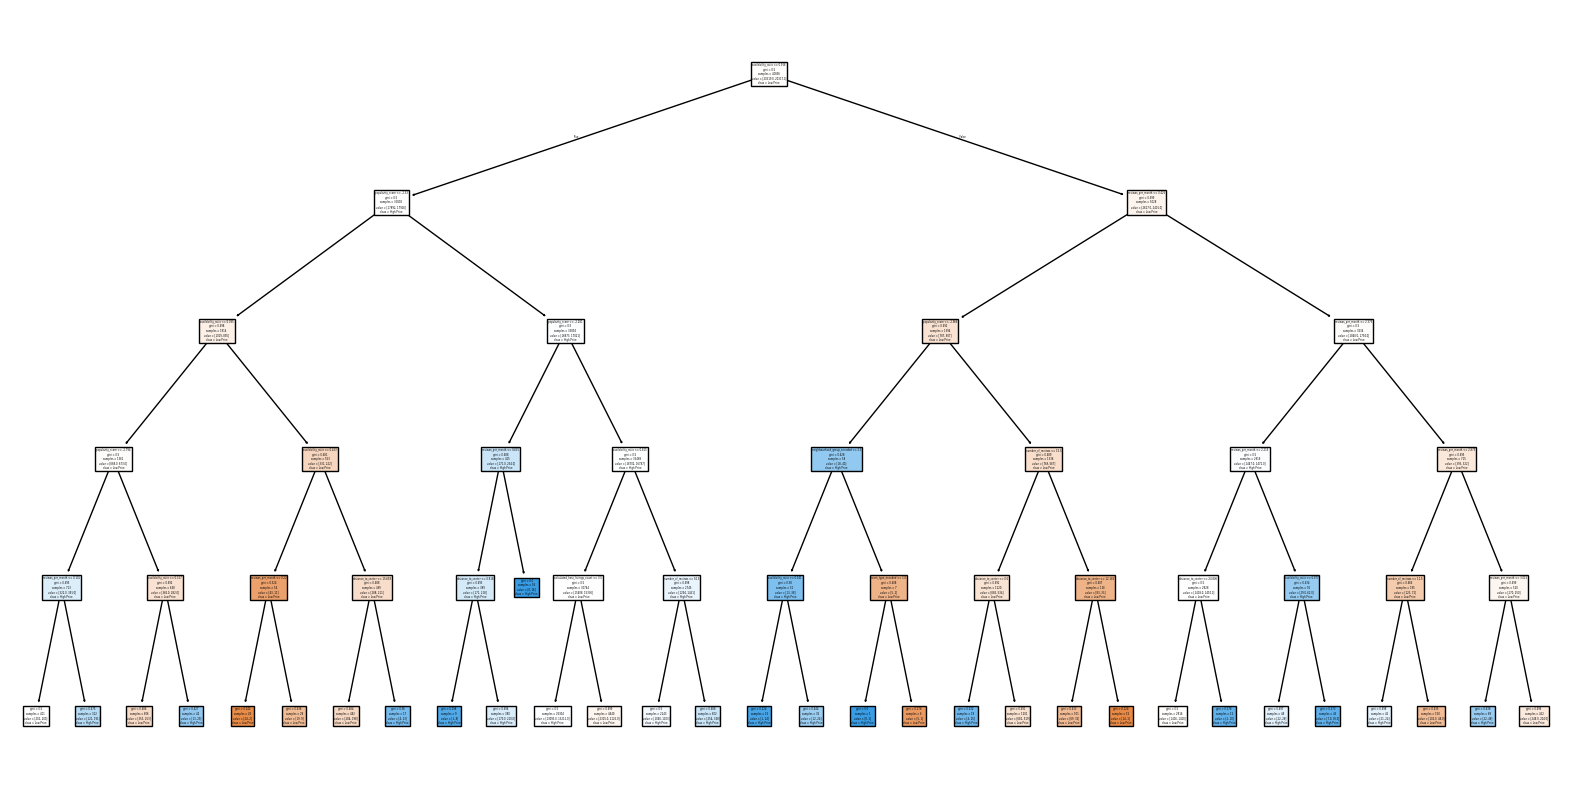

In [86]:
import matplotlib.pyplot as plt
from sklearn.tree import plot_tree

plt.figure(figsize=(20,10))

plot_tree(
    dt,
    feature_names=features,
    class_names=["Low Price","High Price"],
    filled=True
)

plt.show()

## Random Forest

Random Forest je ansambl metoda koja kombinira više stabala odlučivanja.

Svako stablo trenira se na slučajnom podskupu podataka i atributa, a konačna predikcija dobiva se glasanjem svih stabala.

U ovom radu Random Forest koristimo za predikciju varijable high_price i usporedbu rezultata s jednostavnim Decision Tree modelom.

In [66]:
from sklearn.ensemble import RandomForestClassifier

In [87]:
rf = RandomForestClassifier(
    n_estimators=100,
    random_state=42
)

rf.fit(X_train, y_train)

y_pred_rf = rf.predict(X_test)

In [88]:
print("Accuracy:", accuracy_score(y_test, y_pred_rf))
print("Precision:", precision_score(y_test, y_pred_rf))
print("Recall:", recall_score(y_test, y_pred_rf))
print("F1:", f1_score(y_test, y_pred_rf))

Accuracy: 0.6636301302772064
Precision: 0.6690647482014388
Recall: 0.6408741878322505
F1: 0.6546661303298471


In [89]:
cm_rf = confusion_matrix(y_test, y_pred_rf)

print(cm_rf)

[[3520 1610]
 [1824 3255]]


In [90]:
print(classification_report(y_test, y_pred_rf))

              precision    recall  f1-score   support

           0       0.66      0.69      0.67      5130
           1       0.67      0.64      0.65      5079

    accuracy                           0.66     10209
   macro avg       0.66      0.66      0.66     10209
weighted avg       0.66      0.66      0.66     10209



In [91]:
importance = pd.DataFrame({
    "Feature": X_train.columns,
    "Importance": rf.feature_importances_
})

importance = importance.sort_values(
    by="Importance",
    ascending=False
)

importance

,Feature,Importance
0,distance_to_center,0.226073
1,popularity_score,0.157915
2,availability_ratio,0.147411
6,reviews_per_month,0.142120
5,number_of_reviews,0.114871
7,calculated_host_listings_count,0.046910
10,cancellation_policy_encoded,0.037682
9,neighbourhood_group_encoded,0.036561
4,review_rate_number,0.034867
8,room_type_encoded,0.027548


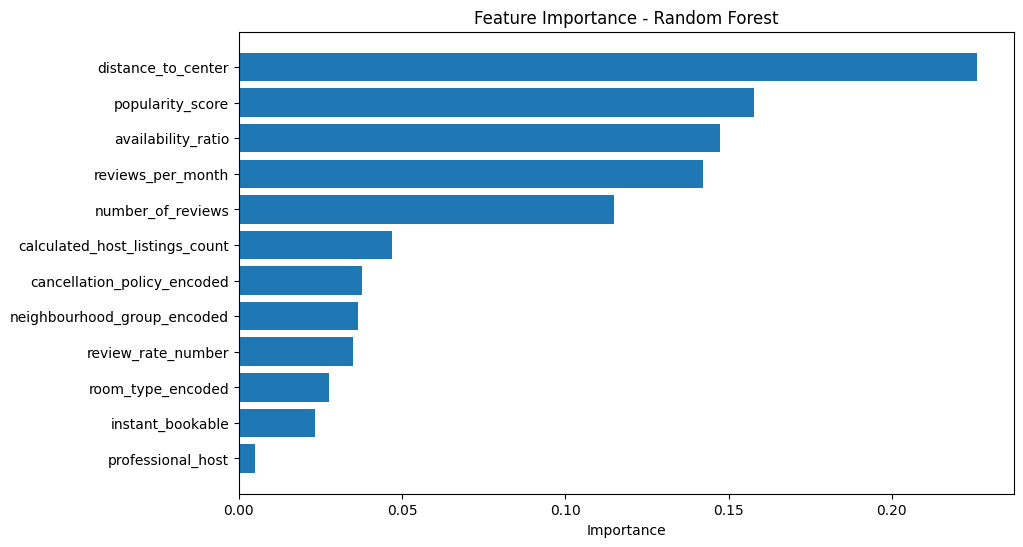

In [92]:
plt.figure(figsize=(10,6))

plt.barh(
    importance["Feature"],
    importance["Importance"]
)

plt.gca().invert_yaxis()
plt.title("Feature Importance - Random Forest")
plt.xlabel("Importance")
plt.show()